# (노트) matplotlib + plotnine 

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [시각화]

### imports

In [434]:
import matplotlib.pyplot as plt 
from plotnine import * 

### 방법1: ggplot으로 figure 오브젝트를 만듬 

In [435]:
p1=ggplot()+geom_point(aes(x=[1,2,3,4],y=[1,2,3,1]))
p2=ggplot()+geom_line(aes(x=[1,2,3,4],y=[1,2,3,1]))

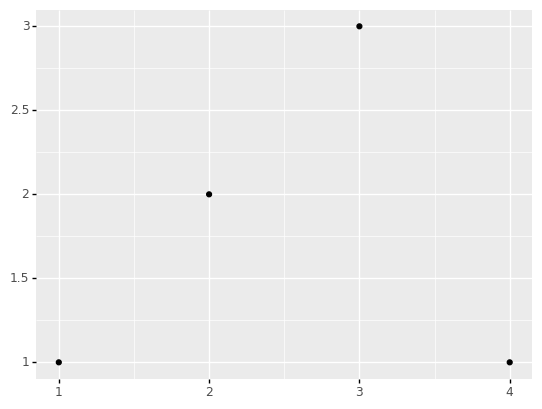

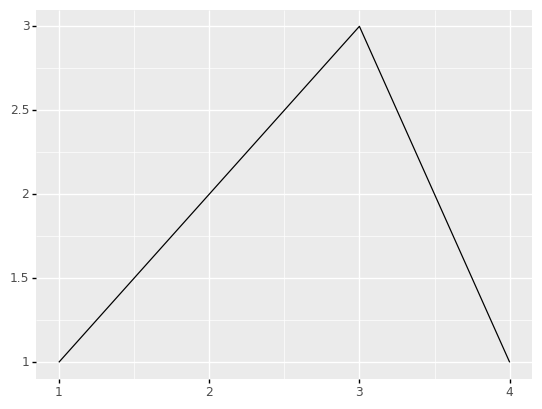

In [436]:
fig = p1.draw()
_fig = p2.draw()

`-` fig에서 ax제거

In [437]:
ax1=fig.axes[0]
fig.delaxes(ax1)

In [438]:
fig

<Figure size 640x480 with 0 Axes>

`-` fig에서 새로운 subplot을 그리고 (0,0)의 액시즈를 지운다. 

In [439]:
ax = fig.subplots(2,2)

In [440]:
ax

array([[<AxesSubplot:>, <AxesSubplot:>],
       [<AxesSubplot:>, <AxesSubplot:>]], dtype=object)

In [441]:
fig.delaxes(ax[0,0])

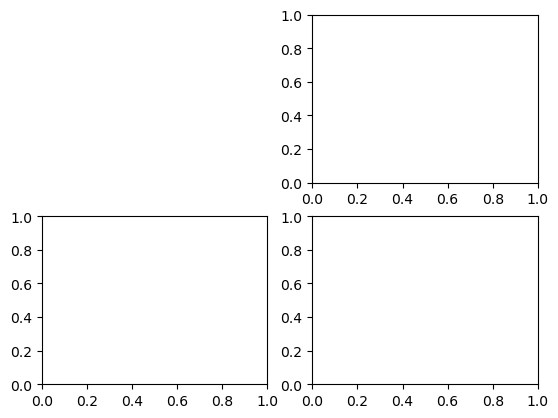

In [442]:
fig

In [443]:
fig.add_subplot(ax1)

<AxesSubplot:>

In [444]:
ax1.set_position(ax[0,0].get_position())

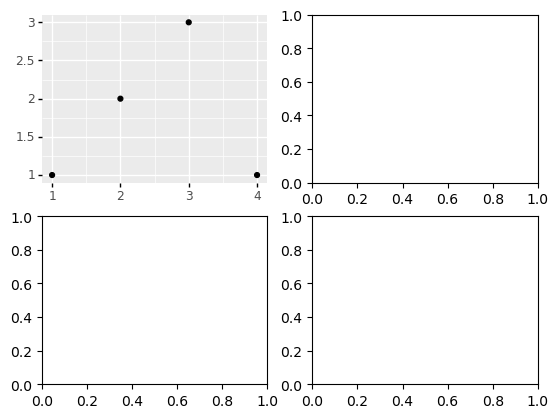

In [445]:
fig

In [446]:
ax1.bbox.height

167.99999999999997

`-` 

In [448]:
ax2 = _fig.axes[0]

In [449]:
ax2.figure = fig 

In [450]:
ax[0,1].remove()

In [451]:
ax2.remove()

In [452]:
ax2.figure = fig

In [453]:
fig.add_subplot(ax2)

<AxesSubplot:>

In [454]:
#ax2.set_position(ax[0,1].get_position())
fig.subplots_adjust(0,0,1,1,1,1)

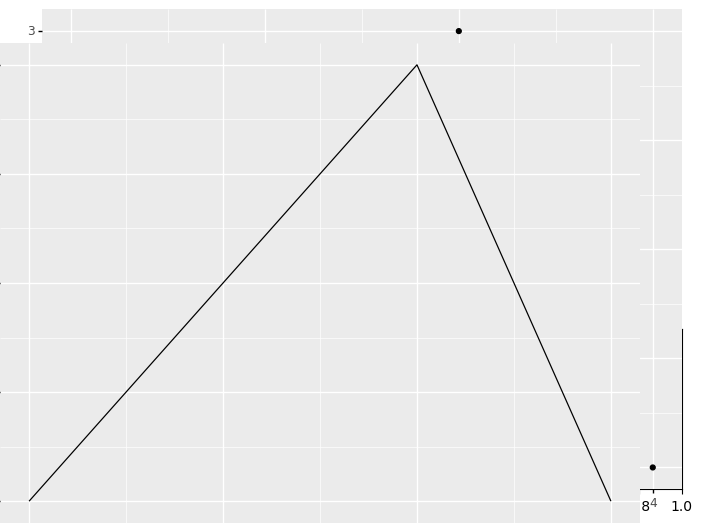

In [455]:
fig

In [354]:
fig.tight_layout()

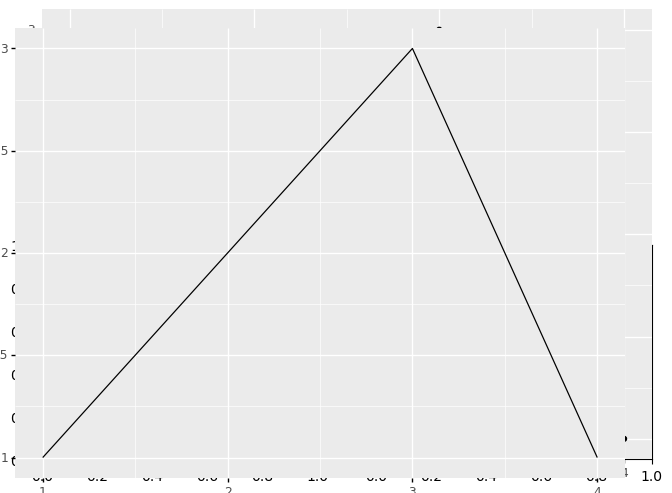

In [355]:
fig

In [286]:
ax2 = _fig.axes[0]

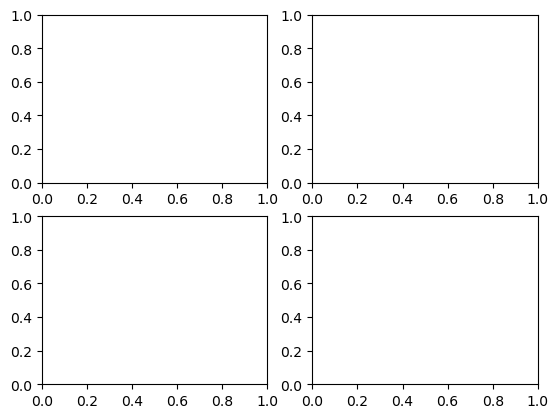

In [10]:
ggfig

In [11]:
ax1.remove()

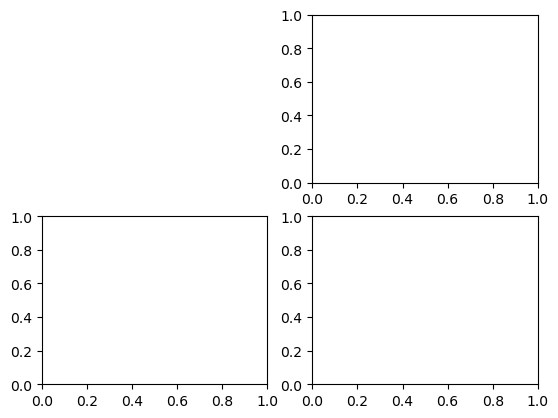

In [12]:
ggfig

In [13]:
ggfig.add_subplot(_ax1)

<AxesSubplot:>

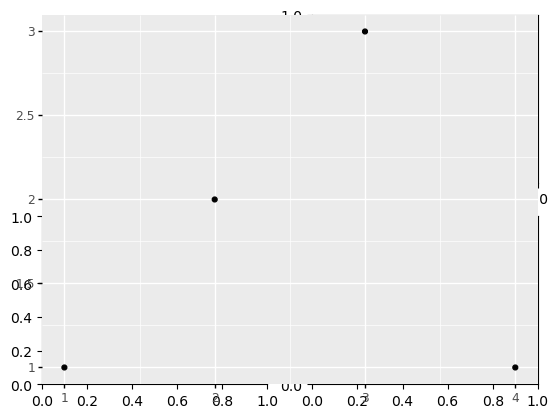

In [14]:
ggfig

In [15]:
ggfig.delaxes(_ax1)

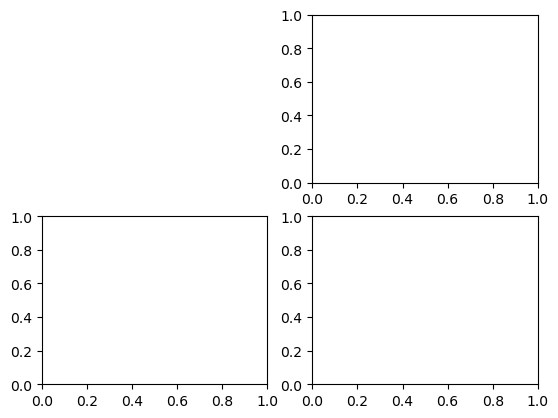

In [16]:
ggfig

In [17]:
# _ax1.axes=None
# _ax1.bbox=ax1.bbox
# _ax1.callbacks
# _ax1.collections
# _ax1.dataLim 
# _ax1.figbox # _ax1.get_position() 
# _ax1.patch
# _ax1.spines
# _ax1.stale_callback
# _ax1.titleOffsetTrans
# _ax1.transAxes
# _ax1.transData
# _ax1.transLimits
# _ax1.transScale
# _ax1.viewLim
# _ax1.xaxis
# _ax1.yaxis

In [18]:
_ax1.set_position(ax1.get_position())

In [19]:
ggfig.add_subplot(_ax1)

<AxesSubplot:>

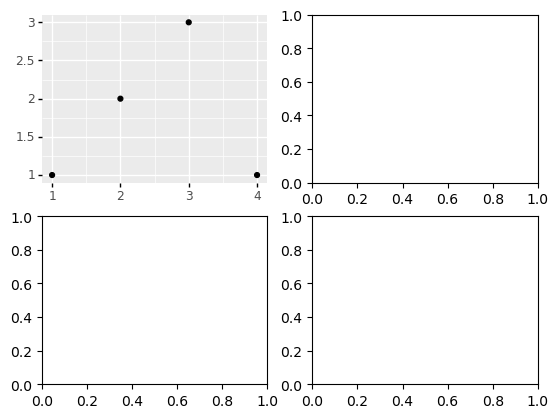

In [20]:
ggfig

In [21]:
ax2.hist([1,2,3,3,4])

(array([1., 0., 0., 1., 0., 0., 2., 0., 0., 1.]),
 array([1. , 1.3, 1.6, 1.9, 2.2, 2.5, 2.8, 3.1, 3.4, 3.7, 4. ]),
 <BarContainer object of 10 artists>)

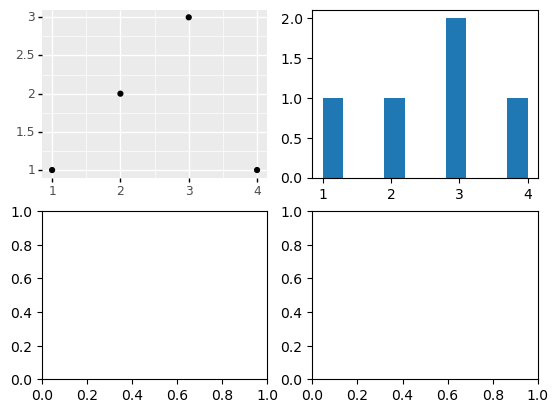

In [22]:
ggfig

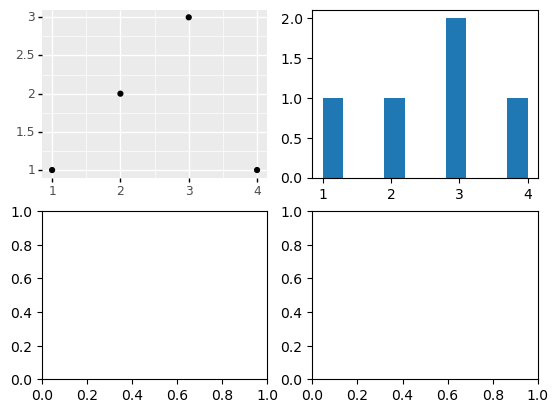

In [23]:
ggfig

### 방법2: matplotlib으로 figure object를 만듬 

`-` matplotlib으로 figure object를 만든다. 

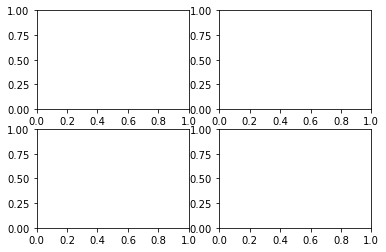

In [247]:
fig,((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2)

`-` ggfig 추출 

In [248]:
_ggfig = ggplot()+geom_point(aes(x=[1,2,3],y=[1,2,3]),colour='red')+theme_matplotlib()

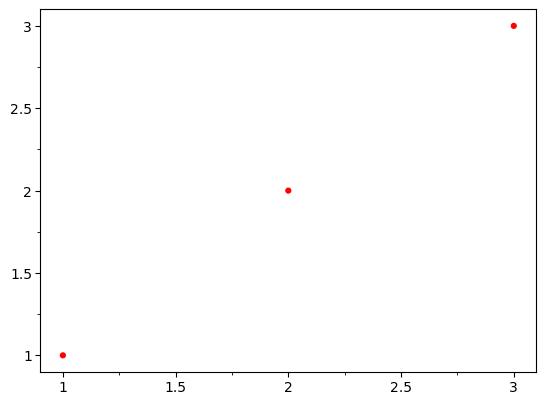

In [249]:
ggfig = _ggfig.draw()

`-` ggfig처럼 fig변경 

In [250]:
fig.set_figheight(ggfig.get_figheight())
fig.set_figwidth(ggfig.get_figwidth())
fig.set_dpi(ggfig.get_dpi())

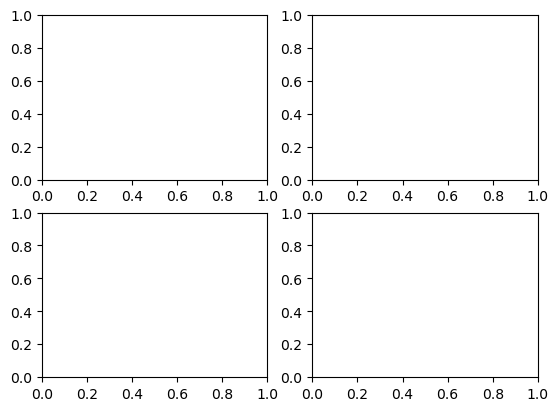

In [251]:
fig

`-` ggfig의 축을 ggax로 저장 

In [252]:
ggax = ggfig.axes[0]

`-` ggax와 ggfig를 분리 

In [253]:
ggax.remove()

`-` ggax의 도화지를 fig로 지정

In [254]:
ggax.figure = fig  ## 등록1 (멤버의 차원)

In [255]:
fig.add_axes(ggax) ## 등록2 (도화지의 차원)

<AxesSubplot:>

`-` 등록결과확인 

In [256]:
fig.axes

[<AxesSubplot:>,
 <AxesSubplot:>,
 <AxesSubplot:>,
 <AxesSubplot:>,
 <AxesSubplot:>]

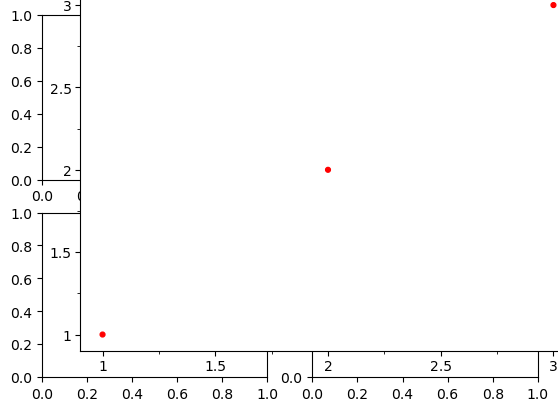

In [257]:
fig

- 이상함 

`-` ax1 제거후 ggax를 ax1자리에 대입

In [258]:
ax1.remove()

In [266]:
ggax.set_position(ax1.get_position())
ggax.set_subplotspec(ax1.get_subplotspec())
#ggax.set_autoscale_on(ax1.get_autoscale_on())
#ggax.set_in_layout(ax1.get_in_layout())

In [267]:
ggax.get_position()

Bbox([[0.0, 0.6666666666666667], [0.3333333333333333, 1.0]])

In [268]:
ax1.get_position()

Bbox([[0.125, 0.5368181818181819], [0.47727272727272724, 0.88]])

In [259]:
fig.subplots_adjust(0,0,1,1,1,1)

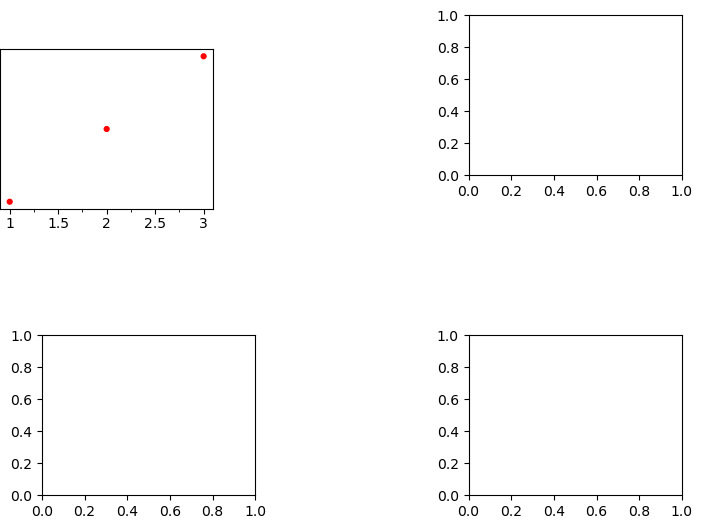

In [262]:
fig

In [224]:
ggax.get_position()

Bbox([[0.07319878472222222, 0.5650462962962963], [0.47099609374999996, 0.9572916666666667]])

In [225]:
ax1.get_position()

Bbox([[0.125, 0.5368181818181819], [0.47727272727272724, 0.88]])

In [200]:
ax1.get_zorder()

0

In [201]:
ggax.get_zorder()

0

In [ ]:
print(ax1.get_adjustable(),ggax.get_adjustable())
print(ax1.get_agg_filter(),ggax.get_agg_filter())
print(ax1.get_alpha(),ggax.get_alpha())
print(ax1.get_anchor(),ggax.get_anchor())
print(ax1.get_animated(),ggax.get_animated())
print(ax1.get_aspect(),ggax.get_aspect())
print(ax1.get_autoscale_on(),ggax.get_autoscale_on())
print(ax1.get_autoscalex_on(),ggax.get_autoscalex_on())
print(ax1.get_autoscaley_on(),ggax.get_autoscaley_on())
print(ax1.get_axisbelow(),ggax.get_axisbelow())
#print(ax1.get_animated(),ggax.get_animated())
#print(ax1.get_aspect(),ggax.get_aspect())


box box
None None
None None
C C
False False
auto auto
True True
True True
True True
line line


`-` 방법2

In [40]:
_fig1 = ggplot()+geom_point(aes(x=[1,2,3],y=[2,3,4]))
_fig2 = ggplot()+geom_point(aes(x=[1,2,3,4],y=[2,3,4,2]),alpha=0.2,size=5)

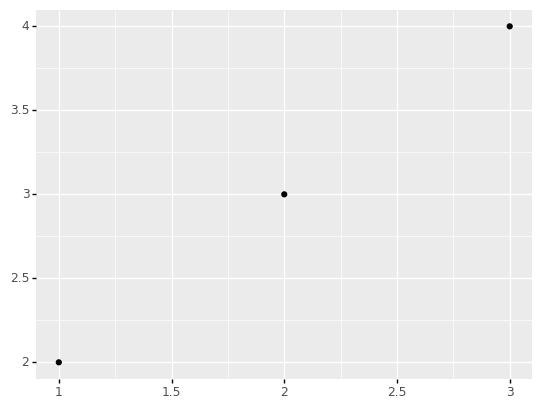

<ggplot: (8787255761734)>

In [41]:
_fig1

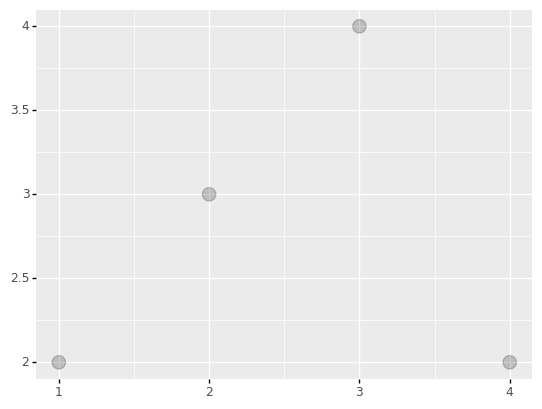

<ggplot: (8787255861815)>

In [42]:
_fig2

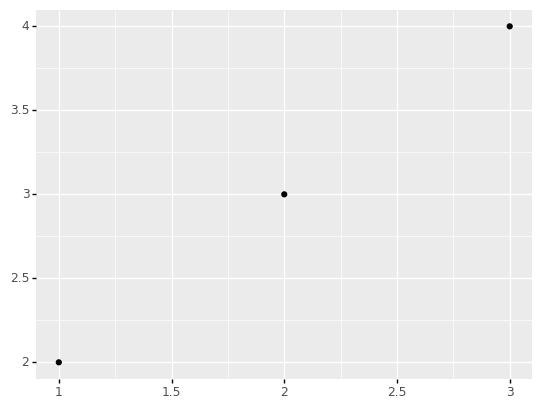

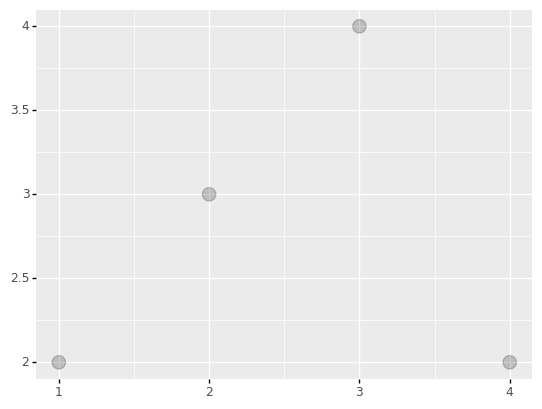

In [43]:
fig1=_fig1.draw()
fig2=_fig2.draw()

In [44]:
ggax1=fig1.axes[0]
ggax2=fig2.axes[0]

In [45]:
fig1.delaxes(ggax1)
ggax2.remove()
ggax2.figure=fig1

In [46]:
(ax1,ax2),(ax3,ax4)=fig1.subplots(2,2)

In [47]:
ax1.remove()
ax4.remove()
ggax1.set_position(ax1.get_position())
ggax2.set_position(ax4.get_position())
fig1.add_axes(ggax1)
fig1.add_axes(ggax2)

<AxesSubplot:>

`-` 테마변경 

In [58]:
#import mplcyberpunk
#plt.style.use("cyberpunk")
#plt.style.use("seaborn")

In [58]:
#import mplcyberpunk
#plt.style.use("cyberpunk")
#plt.style.use("seaborn")

In [58]:
#import mplcyberpunk
#plt.style.use("cyberpunk")
#plt.style.use("seaborn")